This notebook was started using the Advanced RAG cookbook from Huggingface. https://huggingface.co/learn/cookbook/advanced_rag

As we specialize our model for our research we will diverge from this proof of concept system

In [1]:
%pip install -q torch langchain-text-splitters langchain-huggingface transformers accelerate bitsandbytes langchain sentence-transformers faiss-cpu openpyxl pacmap datasets langchain-community ragatouille jedi matplotlib plotly "nbformat>=4.2.0" ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
from tqdm.notebook import tqdm
import pandas as pd
from typing import Optional, List, Tuple
import datasets
import matplotlib.pyplot as plt
import torch


In [3]:
DATASET_NAME = "m-ric/huggingface_doc"
TOKENIZER_NAME = "thenlper/gte-small"

In [4]:

ds = datasets.load_dataset(DATASET_NAME, split="train")
df = ds.to_pandas()
df.head()

,text,source
0,"Create an Endpoint\n\nAfter your first login,...",huggingface/hf-endpoints-documentation/blob/ma...
1,Choosing a metric for your task\n\n**So you'v...,huggingface/evaluate/blob/main/docs/source/cho...
2,主要特点\n\n让我们来介绍一下 Gradio 最受欢迎的一些功能！这里是 Gradio ...,gradio-app/gradio/blob/main/guides/cn/01_getti...
3,!--Copyright 2023 The HuggingFace Team. All ri...,huggingface/transformers/blob/main/docs/source...
4,Gradio Demo: blocks_random_slider\n\n\n```\n!...,gradio-app/gradio/blob/main/demo/blocks_random...


In [5]:
from langchain_core.documents import Document as LangchainDocument

RAW_KNOWLEDGE_BASE = [
    LangchainDocument(page_content=doc["text"], metadata={"source": doc["source"]})
    for doc in tqdm(ds)
]
print(RAW_KNOWLEDGE_BASE[0])

  0%|          | 0/2647 [00:00<?, ?it/s]

page_content=' Create an Endpoint

After your first login, you will be directed to the [Endpoint creation page](https://ui.endpoints.huggingface.co/new). As an example, this guide will go through the steps to deploy [distilbert-base-uncased-finetuned-sst-2-english](https://huggingface.co/distilbert-base-uncased-finetuned-sst-2-english) for text classification. 

## 1. Enter the Hugging Face Repository ID and your desired endpoint name:

<img src="https://raw.githubusercontent.com/huggingface/hf-endpoints-documentation/main/assets/1_repository.png" alt="select repository" />

## 2. Select your Cloud Provider and region. Initially, only AWS will be available as a Cloud Provider with the `us-east-1` and `eu-west-1` regions. We will add Azure soon, and if you need to test Endpoints with other Cloud Providers or regions, please let us know.

<img src="https://raw.githubusercontent.com/huggingface/hf-endpoints-documentation/main/assets/1_region.png" alt="select region" />

## 3. Define the [

Docs done


  0%|          | 0/16776 [00:00<?, ?it/s]

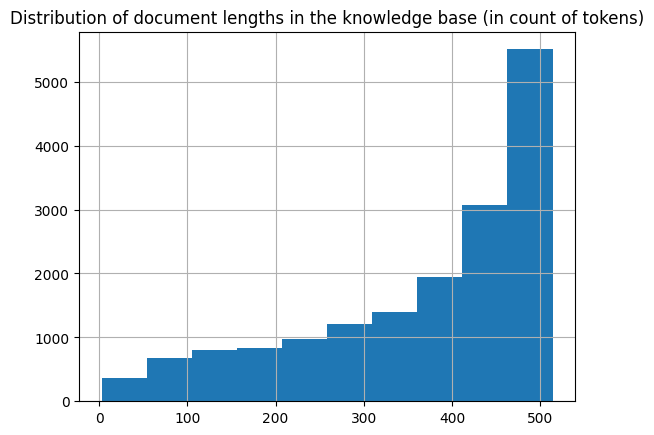

In [6]:
from helper_function import split_knowledge_base

docs_processed = split_knowledge_base(
    512,
    RAW_KNOWLEDGE_BASE,
    tokenizer_name=TOKENIZER_NAME,
)
print("Docs done")

from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)
lengths = [len(tokenizer.encode(doc.page_content)) for doc in tqdm(docs_processed)]
fig = pd.Series(lengths).hist()
plt.title("Distribution of document lengths in the knowledge base (in count of tokens)")
plt.show()

In [7]:
from helper_function import load_knowledge_base

KNOWLEDGE_VECTOR_DATABASE, embedding_model = load_knowledge_base(docs_processed=docs_processed)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: thenlper/gte-small
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading existing FAISS index from 'faiss_index'...


In [8]:
# Test the embedding model by embedding a sample query
user_query = "How to create a pipeline object?"
query_vector = embedding_model.embed_query(user_query)
query_vector

[-0.06402587890625,
 -0.008209228515625,
 0.0204010009765625,
 -0.0297393798828125,
 -0.0672607421875,
 -0.01456451416015625,
 0.01123809814453125,
 0.01226806640625,
 -0.0187225341796875,
 0.036529541015625,
 -0.045562744140625,
 -0.1046142578125,
 0.035400390625,
 -0.01922607421875,
 -0.0055084228515625,
 0.0189056396484375,
 -0.00916290283203125,
 0.0894775390625,
 -0.0762939453125,
 -0.006641387939453125,
 0.07598876953125,
 -0.01678466796875,
 -0.04913330078125,
 -0.054168701171875,
 0.0299530029296875,
 0.0322265625,
 -0.01290130615234375,
 0.005523681640625,
 0.00035691261291503906,
 -0.1868896484375,
 -0.01183319091796875,
 -0.0635986328125,
 0.039581298828125,
 -0.005290985107421875,
 -0.0106964111328125,
 -0.046234130859375,
 -0.007564544677734375,
 0.052032470703125,
 -0.06768798828125,
 0.047515869140625,
 0.04461669921875,
 0.0180206298828125,
 -0.033416748046875,
 -0.04962158203125,
 -0.005191802978515625,
 -0.07373046875,
 -0.04736328125,
 -0.02593994140625,
 0.043060302

In [9]:
# Add additional JSON data to the existing knowledge base
from helper_function import add_json_to_knowledge_base

KNOWLEDGE_VECTOR_DATABASE = add_json_to_knowledge_base(
    path="test_data/test_data.json",
    knowledge_base=KNOWLEDGE_VECTOR_DATABASE,
)

FileNotFoundError: Path does not exist: test_data/test_data.json

In [ ]:
print("***** RETRIEVAL *****")

retrieved_docs = KNOWLEDGE_VECTOR_DATABASE.similarity_search(query=user_query, k=5)

print("***** RESULTS *****")
for idx, doc in enumerate(retrieved_docs):
    print("\n**** SOURCE ****")
    print(f"Source: {doc.metadata['source']}")
    print("\n**** CONTENT ****")
    print(f"Extract: {doc.page_content[:100]}...")

In [ ]:
from model_function import load_reader_model

READER_LLM = load_reader_model()
tokenizer = READER_LLM.tokenizer

#test reader
READER_LLM("Whats the Capitol of Canada?")

In [ ]:
prompt_in_chat_format = [
    {
        "role": "system",
        "content": """Using the information contained in the context,
give a comprehensive answer to the question.
Respond only to the question asked, response should be concise and relevant to the question.
Provide the number of the source document when relevant.
If the answer cannot be deduced from the context, do not give an answer.""",
    },
    {
        "role": "user",
        "content": """Context:
{context}
---
Now here is the question you need to answer.

Question: {question}""",
    },
]
RAG_PROMPT_TEMPLATE = tokenizer.apply_chat_template(
    prompt_in_chat_format, tokenize=False, add_generation_prompt=True
)
print(RAG_PROMPT_TEMPLATE)

In [ ]:
# TODO: Code subject to edit based on experimental needs

retrieved_docs_text = [
    doc.page_content for doc in retrieved_docs
]  # We only need the text of the documents
context = "\nExtracted documents:\n"
context += "".join(
    [f"Document {str(i)}:::\n" + doc for i, doc in enumerate(retrieved_docs_text)]
)

final_prompt = RAG_PROMPT_TEMPLATE.format(
    question="How to create a pipeline object?", context=context
)

# Redact an answer
answer = READER_LLM(final_prompt)[0]["generated_text"]
print(answer)

In [ ]:
# Previous code cells are for RAG pipeline. The following code cells are for visualization of the knowledge base and the query in 2D space using PaCMAP.
# Currently not needed for the RAG pipeline, but can be useful for understanding the distribution of the knowledge base and the query in the embedding space.
import pacmap
import numpy as np
import plotly.express as px

embedding_projector = pacmap.PaCMAP(
    n_components=2, n_neighbors=None, MN_ratio=0.5, FP_ratio=2.0, random_state=1
)

embeddings_2d = [
    list(KNOWLEDGE_VECTOR_DATABASE.index.reconstruct_n(idx, 1)[0])
    for idx in range(len(docs_processed))
] + [query_vector]

# Fit the data (the index of transformed data corresponds to the index of the original data)
documents_projected = embedding_projector.fit_transform(
    np.array(embeddings_2d), init="pca"
)

In [ ]:
df = pd.DataFrame.from_dict(
    [
        {
            "x": documents_projected[i, 0],
            "y": documents_projected[i, 1],
            "source": docs_processed[i].metadata["source"].split("/")[1],
            "extract": docs_processed[i].page_content[:100] + "...",
            "symbol": "circle",
            "size_col": 4,
        }
        for i in range(len(docs_processed))
    ]
    + [
        {
            "x": documents_projected[-1, 0],
            "y": documents_projected[-1, 1],
            "source": "User query",
            "extract": user_query,
            "size_col": 100,
            "symbol": "star",
        }
    ]
)

# Visualize the embedding
fig = px.scatter(
    df,
    x="x",
    y="y",
    color="source",
    hover_data="extract",
    size="size_col",
    symbol="symbol",
    color_discrete_map={"User query": "black"},
    width=1000,
    height=700,
)
fig.update_traces(
    marker=dict(opacity=1, line=dict(width=0, color="DarkSlateGrey")),
    selector=dict(mode="markers"),
)
fig.update_layout(
    legend_title_text="<b>Chunk source</b>",
    title="<b>2D Projection of Chunk Embeddings via PaCMAP</b>",
)
fig.show()